In [1]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np
import matplotlib.pyplot as plt
import argparse
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score


from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel


from tensorflow.keras.layers import add
from tensorflow.keras import mixed_precision

import torch
import sys
import os
import augment_images
from augment_images import main
import importlib

from tqdm.notebook import tqdm




## Flickr - 8 k Data set

In [ ]:
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

import tensorflow as tf

try:
    tf.config.set_visible_devices([], 'GPU')  
    print("GPU (MPS) disabled. Using CPU only.")
except RuntimeError as e:
    print("RuntimeError: TensorFlow already initialized. Restart kernel and run again.")








## Image Augmentation
#### Inorder to introduce variation in the dataset and improve training. Performing image augmentation.
#### Only the training set images are being augmented and augmentation logs are saved

In [ ]:
importlib.reload(augment_images)

flag = True
res = main(flag)
if flag:
    if res:
        print("Augmentation success:", res)
    else:
        print("Augmentation failed:", res)
else:
    print("No augmentation performed.")


## Preparing the data

In [ ]:
def load_doc(filename):
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions = {}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [caption]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

def cleaning_text(captions):
    table = str.maketrans('', '', string.punctuation)
    for img, caps in captions.items():
        for i, img_caption in enumerate(caps):
            img_caption.replace("-", " ")
            desc = img_caption.split()
            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if (len(word) > 1)]
            desc = [word for word in desc if (word.isalpha())]
            img_caption = ' '.join(desc)
            captions[img][i] = img_caption
    return captions

def text_vocabulary(descriptions):
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc)
    data = "\n".join(lines)
    file = open(filename, "w")
    file.write(data)
    file.close()

filename = dataset_text + "/" + "Flickr8k.token.txt"
descriptions = all_img_captions(filename)
print("Length of descriptions =", len(descriptions))

clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary =", len(vocabulary))

save_descriptions(clean_descriptions, "descriptions.txt")


Length of descriptions = 8092
Length of vocabulary =  8763


## Feature Extraction using Vit Encoder

In [ ]:
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")

        # Preprocess image
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Extract features with ViT
        with torch.no_grad():
            outputs = vit_model(**inputs)
        
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features  # Shape: (768,)
    
    return features


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [ ]:
# 768 feature vector for ViT
features = extract_features_vit(dataset_images)
dump(features, open("features.p","wb"))

  0%|          | 0/8091 [00:00<?, ?it/s]

In [ ]:
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos):
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)
    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))
    features = {k: all_features[k] for k in photos}
    return features

def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer

def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)


In [ ]:
filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"

train_imgs = load_photos(filename)

print(f"Loaded {len(train_imgs)} training image filenames.")

train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)
print(f"Loaded features for {len(train_features)} images.")

tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
print(f"Tokenizer created and saved. Vocabulary size: {vocab_size}")

max_length = max_length(descriptions)
print(f"Maximum caption length: {max_length}")


Loaded 6000 training image filenames.
Loaded features for 6000 images.
Tokenizer created and saved. Vocabulary size: 7577
Maximum caption length: 32


### Data Generator

In [ ]:
from keras.utils import to_categorical
import numpy as np

features = load(open("features.p", "rb"))

def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                X1.append(photos[key])
                X2.append(in_seq)
                y.append(out_seq)

    return np.array(X1), np.array(X2), np.array(y)


### Image Captioning Model (Encoder-Decoder Architecture)  
#### The image encoder takes a 768-dimensional feature vector and processes it through dense layers.  
#### The text decoder takes the input caption sequence, embeds it, and processes it through an LSTM to generate word predictions.


In [10]:
def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(768,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = define_model(vocab_size, max_length)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 input_1 (InputLayer)        [(None, 768)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 32, 256)              1939712   ['input_2[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 768)                  0         ['input_1[0][0]']             
                                                                                              

### Training the Image Captioning Model  
#### Initializes training and validation datasets, sets up callbacks (early stopping), and  training for 20 epochs with a batch size of 64.  
#### Using validation loss to monitor overfitting and save the best model.


Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7577
Description Length:  32
Epoch 1/20
4788/4788 [==============================] - 349s 73ms/step - loss: 4.2891 - val_loss: 3.7575 - lr: 0.0010
Epoch 2/20
   1/4788 [..............................] - ETA: 5:37 - loss: 3.4388

/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


4788/4788 [==============================] - 353s 74ms/step - loss: 3.4768 - val_loss: 3.6114 - lr: 0.0010
Epoch 3/20
4788/4788 [==============================] - 363s 76ms/step - loss: 3.1848 - val_loss: 3.6112 - lr: 0.0010
Epoch 4/20
4788/4788 [==============================] - 352s 74ms/step - loss: 3.0057 - val_loss: 3.6516 - lr: 0.0010
Epoch 5/20
4788/4788 [==============================] - 353s 74ms/step - loss: 2.8807 - val_loss: 3.7047 - lr: 0.0010
Epoch 6/20
4788/4788 [==============================] - ETA: 0s - loss: 2.7925
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4788/4788 [==============================] - 357s 74ms/step - loss: 2.7925 - val_loss: 3.7902 - lr: 0.0010
Epoch 7/20
4788/4788 [==============================] - 359s 75ms/step - loss: 2.6365 - val_loss: 3.8360 - lr: 5.0000e-04
Epoch 8/20
4788/4788 [==============================] - 365s 76ms/step - loss: 2.5705 - val_loss: 3.8402 - lr: 5.0000e-04


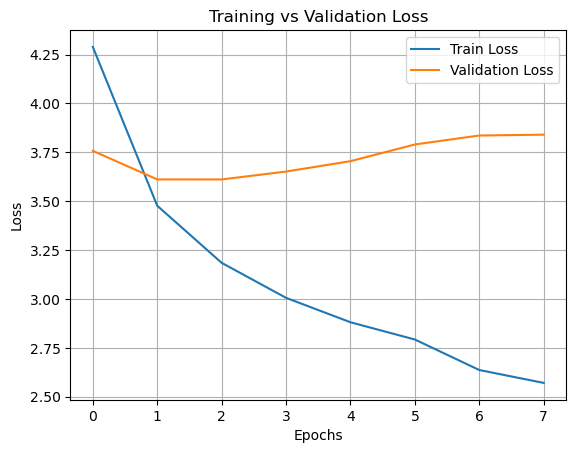

In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("vit_caption_model.h5", monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)

validn_imgs = load_photos("dataset/Flickr8k_text/Flickr_8k.devImages.txt")
dev_descriptions = load_clean_descriptions("descriptions.txt", validn_imgs)
dev_features = load_features(validn_imgs)
X1val, X2val, yval = create_sequences(tokenizer, max_length, dev_descriptions, dev_features, vocab_size)

history = model.fit(
    [X1train, X2train], ytrain,
    validation_data=([X1val, X2val], yval),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

model.save("vit_caption_model.h5")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


### Testing 

### Generating captions from image features using the trained model.  
#### Evaluates generated captions against ground-truth descriptions using BLEU-1 to BLEU-4 and METEOR scores.  
#### Performs evaluation on the test set (Flickr8k) using extracted features and cleaned descriptions.


In [12]:
from tensorflow.keras.models import load_model

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text.replace('start', '').replace('end', '').strip()


def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_from_features(model, tokenizer, photos[key].reshape(1, 768), max_length)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))

    return scores


test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)

# Load everything
model = load_model("vit_caption_model.h5")

results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)


  0%|          | 0/1000 [00:00<?, ?it/s]

In [13]:
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")

Average BLEU-1: 0.4621
Average BLEU-2: 0.2856
Average BLEU-3: 0.1816
Average BLEU-4: 0.1182
Average METEOR: 0.2756




### Evaluation with Beam Search Decoding  
#### Implements a beam search-based caption generator that explores multiple word sequences and selects the most probable one.  
#### The `generate_caption_beam` function uses beam width to maintain the top candidate sequences at each decoding step.  
#### Evaluates the model using BLEU-1 to BLEU-4 and METEOR scores on the test dataset for more accurate caption quality assessment.


In [ ]:
def generate_caption_beam(model, tokenizer, photo, max_length, beam_width=3, start_token='start', end_token='end'):
    sequences = [[[tokenizer.word_index[start_token]], 0.0, []]]

    for _ in range(max_length):
        all_candidates = []

        for seq, score, words in sequences:
            if words and words[-1] == end_token:
                all_candidates.append((seq, score, words))
                continue

            padded_seq = pad_sequences([seq], maxlen=max_length, padding='post')
            preds = model.predict([photo, padded_seq], verbose=0)

            if preds.ndim != 2 or preds.shape[0] != 1:
                print(f"Unexpected prediction shape: {preds.shape}")
                continue

            vocab_logits = preds[0]
            vocab_logits = np.array(vocab_logits, dtype=np.float64)
            vocab_logits[0] = -1.0

            top_indices = np.argsort(vocab_logits)[-beam_width:]
            for idx in top_indices:
                word = word_for_id(idx, tokenizer)
                if word is None:
                    continue
                new_seq = seq + [idx]
                new_score = score - np.log(vocab_logits[idx] + 1e-9)
                new_words = words + [word]
                all_candidates.append((new_seq, new_score, new_words))

        ordered = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = ordered[:beam_width]

        if not sequences:
            print("Warning: No sequences left at step", _)
            return ""

    best_seq = sequences[0][2]
    caption = ' '.join([w for w in best_seq if w not in [start_token, end_token]])
    return caption.strip()

def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        try:
            photo_feat = photos[key].reshape(1, 768)
            yhat = generate_caption_beam(model, tokenizer, photo_feat, max_length, beam_width=5)
        except Exception as e:
            print(f"Failed to generate caption for {key}: {e}")
            continue

        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))

    return scores

test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)
results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)


  0%|          | 0/1000 [00:00<?, ?it/s]

### Visualizing and Summarizing Model Performance  
#### Displays sample images along with their generated captions, ranked by BLEU-4 score.  
#### The `summarize_scores` function prints average BLEU-1 to BLEU-4 and METEOR scores across the test set.  
#### Top and bottom 5 captions are visualized to qualitatively assess the model’s strengths and weaknesses.


Average BLEU-1: 0.4501
Average BLEU-2: 0.2936
Average BLEU-3: 0.1921
Average BLEU-4: 0.1264
Average METEOR: 0.2786


 Top 5 Captions by BLEU-4:

Image: 2985679744_75a7102aab.jpg
Caption: man is sitting on train
BLEU-4: 0.8187


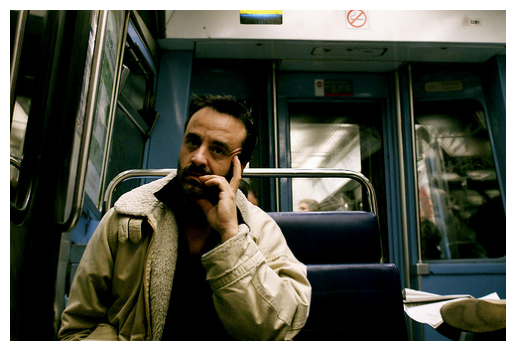

Image: 115684808_cb01227802.jpg
Caption: two people are standing in the snow
BLEU-4: 0.8091


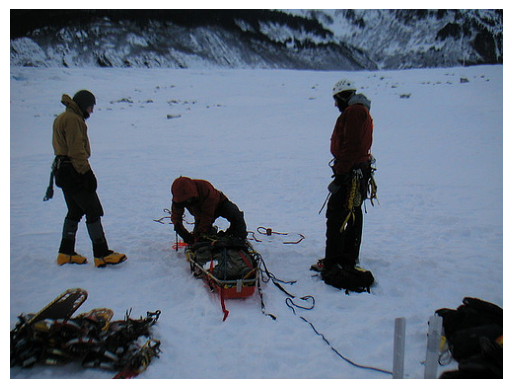

Image: 3167365436_c379bda282.jpg
Caption: man and woman pose for picture
BLEU-4: 0.7598


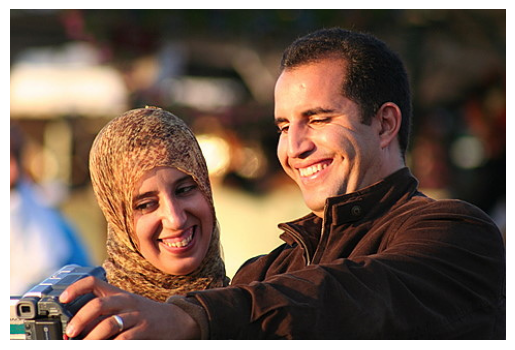

Image: 500446858_125702b296.jpg
Caption: white dog is running on the grass
BLEU-4: 0.7071


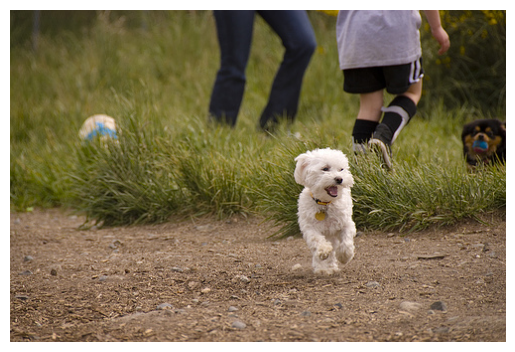

Image: 3363750526_efcedc47a9.jpg
Caption: black and white dog is running through the sand
BLEU-4: 0.6606


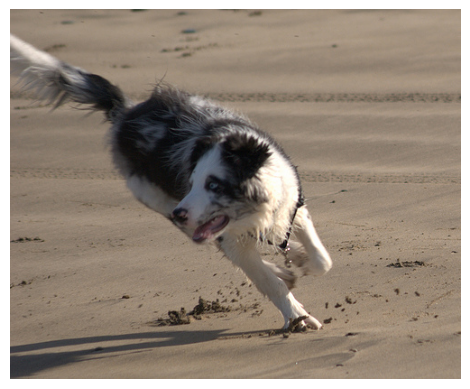


 Bottom 5 Captions by BLEU-4:

Image: 2206960564_325ed0c7ae.jpg
Caption: two dogs are playing with each other
BLEU-4: 0.0000


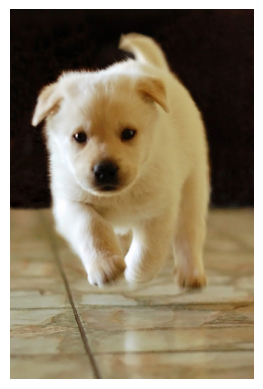

Image: 2934359101_cdf57442dc.jpg
Caption: two men are playing basketball
BLEU-4: 0.0000


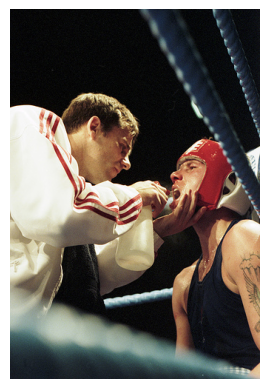

Image: 3123463486_f5b36a3624.jpg
Caption: two dogs are playing with each other
BLEU-4: 0.0000


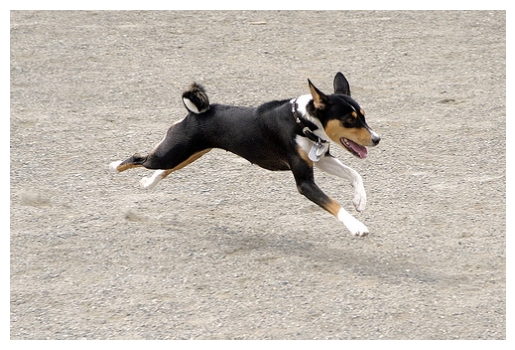

Image: 3157847991_463e006a28.jpg
Caption: man and woman sitting on bench
BLEU-4: 0.0000


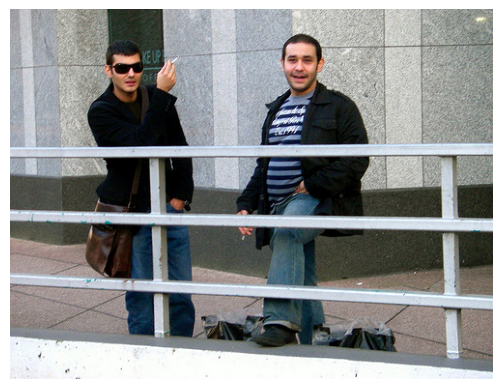

Image: 3228069008_edb2961fc4.jpg
Caption: two dogs are playing with each other
BLEU-4: 0.0000


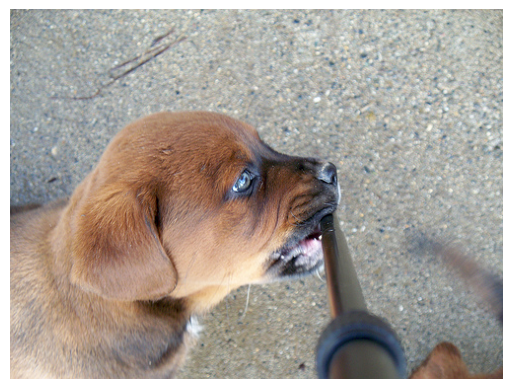

In [ ]:
def display_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")
image_dir = "dataset/Flicker8k_Dataset/"

# Top 5 by BLEU-4  

sorted_by_bleu4 = sorted(results, key=lambda x: x[5], reverse=True)
print(" Top 5 Captions by BLEU-4:\n")
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))


## BOTTOM 5 BY BLEU-4

print("\n Bottom 5 Captions by BLEU-4:\n")
sorted_by_bleu4 = sorted(results, key=lambda x: x[5])
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))













### Plots

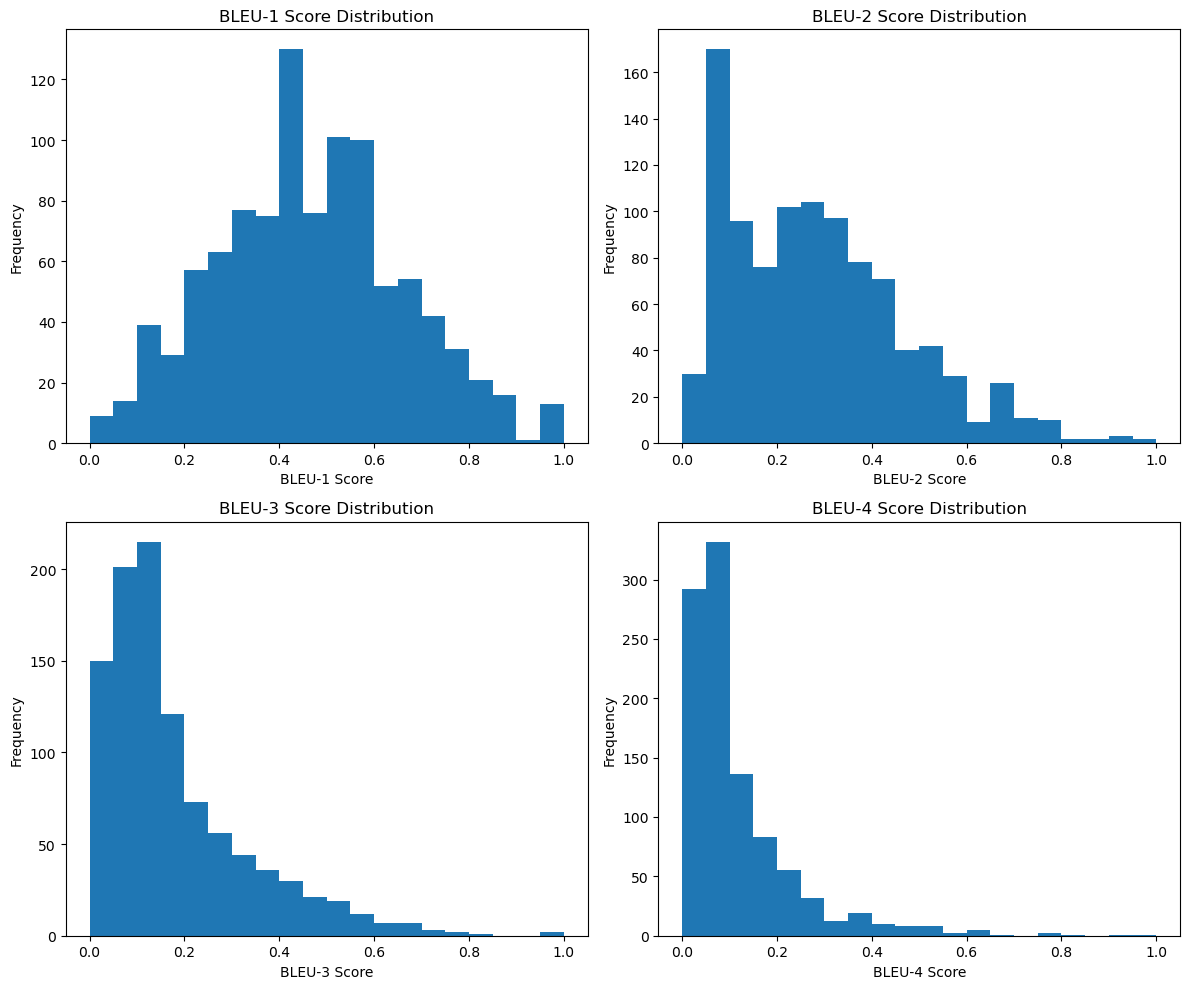

In [26]:
import matplotlib.pyplot as plt

# Extract BLEU scores from your results (adjust indices if needed)
bleu1 = [r[2] for r in results]
bleu2 = [r[3] for r in results]
bleu3 = [r[4] for r in results]
bleu4 = [r[5] for r in results]
meteor = [r[6] for r in results]

# Set up 2x2 grid of plots
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(bleu1, bins=20)
plt.title("BLEU-1 Score Distribution")
plt.xlabel("BLEU-1 Score")
plt.ylabel("Frequency")

plt.subplot(2, 2, 2)
plt.hist(bleu2, bins=20)
plt.title("BLEU-2 Score Distribution")
plt.xlabel("BLEU-2 Score")
plt.ylabel("Frequency")

plt.subplot(2, 2, 3)
plt.hist(bleu3, bins=20)
plt.title("BLEU-3 Score Distribution")
plt.xlabel("BLEU-3 Score")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(bleu4, bins=20)
plt.title("BLEU-4 Score Distribution")
plt.xlabel("BLEU-4 Score")
plt.ylabel("Frequency")


plt.tight_layout()
plt.show()


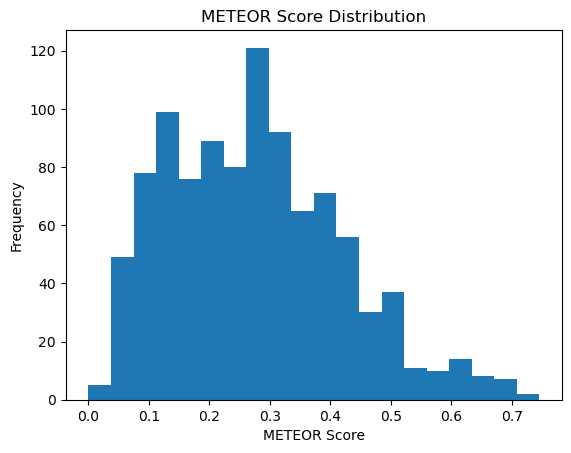

In [27]:

meteor = [r[6] for r in results]

plt.hist(meteor, bins=20)
plt.title("METEOR Score Distribution")
plt.xlabel("METEOR Score")
plt.ylabel("Frequency")
plt.show()


## Testing gradio

In [ ]:
import sqlite3
import numpy as np
import torch
import pickle
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import ViTFeatureExtractor, ViTModel

tokenizer = pickle.load(open("tokenizer.p", "rb"))
max_length = 32
caption_model = load_model('vit_caption_model.h5')
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

DB_FILE = "images.db"

def init_db():
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS images (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                image BLOB NOT NULL,
                caption TEXT NOT NULL,
                embedding BLOB NOT NULL
            )
        ''')
        conn.commit()

init_db()

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None or word == 'end':
            break
        in_text += ' ' + word
    return in_text.replace("start", "").strip()

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)
    photo = vit_features.reshape(1, 768).numpy()
    caption = generate_caption_from_features(caption_model, tokenizer, photo, max_length)
    saveImageDesc(image_path, caption, photo.squeeze())
    return caption

def saveImageDesc(img_path, caption, embedding):
    img = Image.open(img_path)
    img_bytes = BytesIO()
    img.save(img_bytes, format="PNG")
    img_data = img_bytes.getvalue()
    emb_blob = pickle.dumps(embedding)
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("INSERT INTO images (image, caption, embedding) VALUES (?, ?, ?)", 
                       (img_data, caption, emb_blob))
        conn.commit()

def search_images(keyword):
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
        rows = cursor.fetchall()
    images = [Image.open(BytesIO(row[0])) for row in rows] if rows else []
    return gr.Gallery(images, columns=2)

def image_to_image_search(query_path, threshold=0.80):
    query_img = Image.open(query_path).convert("RGB")
    inputs = feature_extractor(images=query_img, return_tensors="pt")
    with torch.no_grad():
        query_embedding = vit_model(**inputs).last_hidden_state[:, 0, :].squeeze().numpy()
        query_embedding /= np.linalg.norm(query_embedding)
    results = []
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image, embedding FROM images")
        for row in cursor.fetchall():
            img_data, emb_blob = row
            stored_embedding = pickle.loads(emb_blob)
            stored_embedding /= np.linalg.norm(stored_embedding)
            sim = cosine_similarity([query_embedding], [stored_embedding])[0][0]
            if sim >= threshold:
                results.append((sim, img_data))
    results.sort(reverse=True, key=lambda x: x[0])
    top_images = [Image.open(BytesIO(r[1])) for r in results[:5]]
    return gr.Gallery(top_images, columns=2)

caption_iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Image Caption Generator",
    description="Upload an image to generate a caption and store it locally."
)

search_text_iface = gr.Interface(
    fn=search_images,
    inputs="text",
    outputs=gr.Gallery(),
    title="Search Images by Text",
    description="Search images based on their generated captions."
)

search_image_iface = gr.Interface(
    fn=image_to_image_search,
    inputs=[
        gr.Image(type="filepath", label="Query Image"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.80, label="Similarity Threshold")
    ],
    outputs=gr.Gallery(),
    title="Search Images by Image",
    description="Upload an image and filter similar results by cosine similarity."
)

gr.TabbedInterface(
    [caption_iface, search_text_iface, search_image_iface],
    ["Generate Caption", "Search by Text", "Search by Image"]
).launch()


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
